In [9]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
import pandas as pd
import rioxarray
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})

In [2]:
def bins_plot_areas(values):
    # Define bin boundaries for value categorization
    boundary = np.array([50, 100, 150, 200])
    # Define output size values for each bin
    size_bins = [10, 50, 100, 200, 300]
    
    # Categorize input values into bins and assign corresponding size values
    size = np.piecewise(
        values,
        # Define conditions for each bin
        [values < boundary[0],                         # Bin 1: values < 50
         (values >= boundary[0]) & (values < boundary[1]),  # Bin 2: 50 ≤ values < 100
         (values >= boundary[1]) & (values < boundary[2]),  # Bin 3: 100 ≤ values < 150
         (values >= boundary[2]) & (values < boundary[3]),  # Bin 4: 150 ≤ values < 200
         values >= boundary[3]],                       # Bin 5: values ≥ 200
        
        # Assign corresponding size values for each bin
        [lambda x: size_bins[0],  # Return 10 for bin 1
         lambda x: size_bins[1],  # Return 50 for bin 2
         lambda x: size_bins[2],  # Return 100 for bin 3
         lambda x: size_bins[3],  # Return 200 for bin 4
         lambda x: size_bins[4]]) # Return 300 for bin 5
    
    return size

In [4]:
# Load soil moisture data and extract the last dimension
ysomo = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
# Calculate minimum and maximum values of soil moisture data (ignoring NaN values)
ymin_somo = np.nanmin(ysomo)
ymax_somo = np.nanmax(ysomo)

# Load drought events data from CSV file (using first column as index)
df = pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/droughts_new_all_events_mean.csv", index_col=0)
# Transform EGS values using soil moisture range scaling
df["egs"] = df["egs"] * 100 * (ymax_somo - ymin_somo) * 2

# Load comparison drought events data from another CSV file
df2 = pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/droughts/esa_era/droughts_new_all_events_mean.csv", index_col=0)
# Invert EGS values for the second dataset (make negative)
df2["egs"] = -df2["egs"]

/tmp/ipykernel_2676690/2498387071.py:47: UltraPlotWarning: fig.subplots_adjust() has no effect on ultraplot figures. To set the left, right, bottom, top, wspace, or hspace gridspec values, pass them as keyword arguments to uplt.figure() or uplt.subplots(). Please note they are now specified in physical units, with strings interpreted by uplt.units() and floats interpreted as font size-widths.
  fig.subplots_adjust()


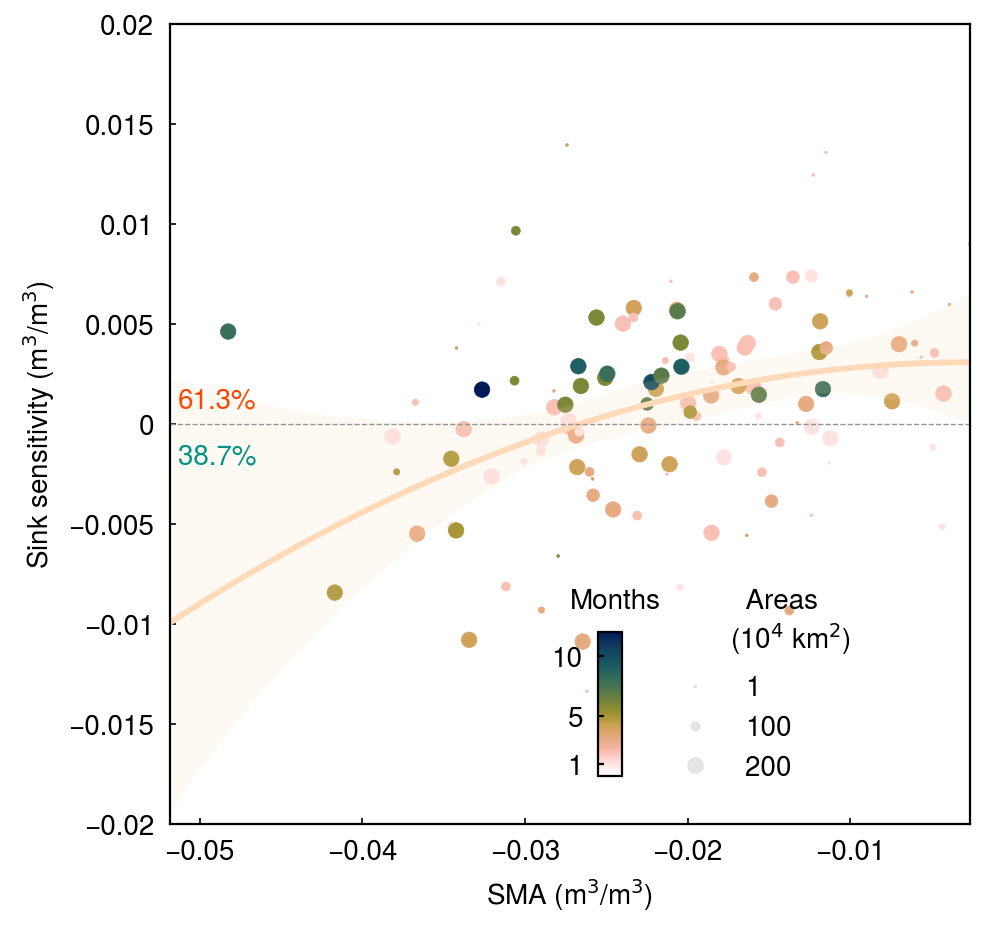

In [72]:
# Define subplot arrangement (1 == subplot A)
arrray = [[1, ]]  # Single subplot layout

# Create figure with custom layout parameters
fig = uplt.figure(refwidth=4, share=False, span=False, tight=True)
# Create subplot according to the array layout
axs = fig.subplots(arrray, abc=0, width_ratios=[1], height_ratios=[1])
ax1 = axs  # Main axis reference

# Calculate marker sizes based on area values (scaled by 2000)
size_somo_areas = bins_plot_areas(values=(df.mean_area/2000).values)
# Create scatter plot: SMA vs EGS with size=area, color=months
sc1 = ax1.scatter(df.sma, df.egs, s=size_somo_areas, c=df.months, 
                  norm=Normalize(0,12), cmap='batlowW_r')
# Add polynomial regression fit (order 2)
sb1 = sns.regplot(x='sma', y='egs', data=df, scatter=0, color='peachpuff', order=2, ax=ax1)

# Create inset colorbar for months
ax_cb2 = inset_axes(ax1, width="5%", height="30%", borderpad=0, 
                   bbox_to_anchor=(0.25, -0.15, 0.6, 0.6), 
                   bbox_transform=ax1.transAxes, loc='center')
cb2 = fig.colorbar(sc1, cax=ax_cb2, fraction=0.01, pad=0.1, shrink=1, 
                  ticks=[1,5,10], ticklocation='left')

# Create legend for area sizes (marker sizes)
handles1, labels1 = sc1.legend_elements(prop="sizes", alpha=0.1)
used_labels1 = ['1', '100', '200']  # Custom legend labels for area sizes
ax1.legend([handles1[0], handles1[2], handles1[4]], used_labels1, 
           bbox_to_anchor=(0.7, 0.12), ncol=1, loc='center', frameon=False)

# Set axis labels
ax1.set_xlabel("SMA (m$^3$/m$^3$)")
ax1.set_ylabel("Sink sensitivity (m$^3$/m$^3$)")

# Add text annotations
ax1.text(0.5, 0.27, "Months", transform=ax1.transAxes)
ax1.text(0.7, 0.22, "  Areas \n(10$^4$ km$^2$)", transform=ax1.transAxes)
# Add horizontal reference line at y=0
ax1.axhline(y=0, color='grey', linestyle='--', linewidth=0.5)
# Set y-axis limits
ax1.set_ylim(-0.02, 0.02)
# Add percentage annotations
ax1.text(0.01, 0.52, '61.3%', transform=ax1.transAxes, color='orangered')
ax1.text(0.01, 0.45, '38.7%', transform=ax1.transAxes, color='teal')

# (Commented out) Additional dataset visualization code
# size_esa_areas=bins_plot_areas(values=(df2.mean_area/10000).values)
# sc2=ax1.scatter(df2.sma,df2.egs,s=size_esa_areas,c=df2.months,norm=Normalize(0,12),cmap='batlowW',marker='^')
# sb2=sns.regplot(x='sma',y='egs',data=df2,scatter=0,color='darksalmon', order=2,ax=ax1)
# handles2,labels2=sc2.legend_elements(prop="sizes",alpha=0.1)
# fig.legend([handles2[0],handles2[2],handles2[3]], used_labels1, loc='t', bbox_to_anchor=(0.60, 0.22),frameon=False, fontsize=14)

# Adjust subplot layout
fig.subplots_adjust()